In [8]:
import sys
import optuna
import numpy as np
import pandas as pd
from itertools import combinations

sys.path.append("..")
from feature_engineering import time_based_train_test_split, get_return, round_to_step, get_mask
from etl_pipeline_local import get_btts_table, get_match_data

pd.set_option('display.max_columns', None)
target_col = "btts"
odds_col: str = "goalNoGoal_quote_currentGG"

In [9]:
# TODO: far scegliere a Optuna se tenere o meno una variabile
# TODO: aggiungere early stopping
# TODO: perfezionare funzione di costo per tradeoff roi medio e quantità di partite considerate
# TODO: logging risultati
# TODO: analisi  univariata KPI più promettenti (Optional)

In [15]:
# Load data
df_loaded = get_btts_table()

df_loaded = df_loaded.sort_values('time').reset_index(drop=True)

# Train/test split
df = df_loaded.copy()
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x["goalNoGoal_quote_currentGG"]), axis=1).copy()

# Adding week column 
df["week"] = df["time"].dt.to_period("W")
monday_start = df["time"].min() - pd.to_timedelta(df["time"].min().weekday(), unit="D")
df["week"] = ((df["time"] - monday_start).dt.days // 7) + 1


df_train, df_test = time_based_train_test_split(df=df, time_col="time", train_frac=0.8)

In [ ]:
# Define features and relative step
# feature_bins_map = {
#     'goalNoGoal_chance_goalHome': 2.5,
#     'goalNoGoal_chance_goalAway': 2.5, 
#     'goalNoGoal_comparison_affini': 2000,
#     'underOver_chance_over15HT': 5,
#     'underOver_comparison_affini': 2000,
#     'evaluation_valScala': None,
#     'evaluation_valMetrica': None,
#  }

feature_bins_map={
    "evaluation_valScala":None,
    "evaluation_valMetrica":None,
    "underOver_chance_over15HT":5,
    "chance1x2_quote_current1":0.1,
    "chance1x2_quote_current2":0.1,
    "goalNoGoal_quote_currentGG":0.1,
    "goalNoGoal_chance_goal":5,
    "goalNoGoal_flashback_goal":5,
    "goalNoGoal_stats_avgGoalHome":0.1,
    "goalNoGoal_stats_avgGoalTakenAway":0.1,
    "goalNoGoal_stats_avgGoalTakenHome":0.1,
    "goalNoGoal_stats_avgGoalAway":0.1
}
 
# Create the binned dataframe
df_train_binned = df_train.copy()

    
for feat, step in feature_bins_map.items():
    df_train_binned[feat] = [round_to_step(x, step) for x in df_train_binned[feat]]

    if isinstance(step, int):
        df_train_binned[feat] = df_train_binned[feat].astype("Int64")

print("SEARCH SPACE\n")
for feat in feature_bins_map.keys():
    space = df_train_binned[feat].sort_values(ascending=True).unique()
    print(f"Feature: {feat}")
    print(f"Search space: {space}")
    print("\n")

SEARCH SPACE

Feature: evaluation_valScala
Search space: ['48727' '49657' '49867' '50827' '<NA>']


Feature: evaluation_valMetrica
Search space: ['114521' '147930' '221599' '225586' '354214' '398418' '494608' '757193'
 '<NA>']


Feature: underOver_chance_over15HT
Search space: <IntegerArray>
[15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]
Length: 12, dtype: Int64


Feature: chance1x2_quote_current1
Search space: [ 1.   1.1  1.2  1.3  1.4  1.5  1.6  1.7  1.8  1.9  2.   2.1  2.2  2.3
  2.4  2.5  2.6  2.7  2.8  2.9  3.   3.1  3.2  3.3  3.4  3.5  3.6  3.7
  3.8  3.9  4.   4.1  4.2  4.3  4.5  4.7  4.8  4.9  5.   5.2  5.5  5.6
  5.7  6.   6.2  6.5  7.   7.5  8.   8.5  9.   9.5 10.  11.  12.  13.
 15. ]


Feature: chance1x2_quote_current2
Search space: [ 1.1  1.2  1.3  1.4  1.5  1.6  1.7  1.8  1.9  2.   2.1  2.2  2.3  2.4
  2.5  2.6  2.7  2.8  2.9  3.   3.1  3.2  3.3  3.4  3.5  3.6  3.7  3.8
  3.9  4.   4.1  4.2  4.3  4.4  4.5  4.6  4.7  4.9  5.   5.2  5.5  5.7
  5.9  6.   6.2  6.5  7.   7.1

In [ ]:
def objective(trial, min_obs, _lambda):
    mask = pd.Series(True, index=df_train_binned.index)

    for feat, step in feature_bins_map.items():

        s = df_train_binned[feat]
        non_null = s.dropna()

        if non_null.empty:
            continue

        # ---------------------------------
        # CASO 1: variabile categorica
        # ---------------------------------
        if not step:
            # ordine stabile e deterministico
            unique_vals = sorted(map(str, non_null.unique()))

            categorical_set = [
                list(c)
                for r in range(1, len(unique_vals) + 1)
                for c in combinations(unique_vals, r)
            ]

            idx = trial.suggest_categorical(
                f"{feat}_cat_idx",
                list(range(len(categorical_set)))
            )

            categorical_feat = categorical_set[idx]
            trial.set_user_attr(f"{feat}_cat", categorical_feat)


        # ---------------------------------
        # CASO 2: numerica continua/intera
        # ---------------------------------
        else:
            # TODO: se la feature ha valori nulli, introduco include_missing feature, valutare rimozione  
            if s.isna().sum() > 0:
                include_missing = trial.suggest_categorical(
                    f"{feat}_include_missing",
                    [True, False]
                )
                trial.set_user_attr(f"{feat}_include_missing", include_missing)

            # TODO: vincolo per >=, <=, <,>, da studiare
            use_min = trial.suggest_categorical(f"{feat}_use_min", [True, False])
            use_max = trial.suggest_categorical(f"{feat}_use_max", [True, False])

            trial.set_user_attr(f"{feat}_use_min", use_min)
            trial.set_user_attr(f"{feat}_use_max", use_max)

            # TODO: questo dovrebbe forzare l'utilizzo della feature, da capire se forzarlo è utile o meno
            # # almeno un vincolo deve essere attivo
            if not use_min and not use_max:
                raise optuna.TrialPruned()
            
            if pd.api.types.is_integer_dtype(s):
                feat_min = trial.suggest_int(
                    name=f"{feat}_min",
                    low=int(non_null.min()),
                    high=int(non_null.max()) - step, # considero upper bound meno step
                    step=step
                )
                feat_max = trial.suggest_int(
                    name=f"{feat}_max",
                    low=feat_min + step, # considero lower bound più step
                    high=int(non_null.max()), 
                    step=step
                )
                trial.set_user_attr(f"{feat}_min", feat_min)
                trial.set_user_attr(f"{feat}_max", feat_max)
            else:
                feat_min = trial.suggest_float(
                    name=f"{feat}_min",
                    low=float(non_null.min()),
                    high=float(non_null.max()) - step, # considero upper bound meno step
                    step=step
                )
                feat_max = trial.suggest_float(
                    name=f"{feat}_max",
                    low=feat_min + step, # considero lower bound più step
                    high=float(non_null.max()),
                    step=step
                )
                trial.set_user_attr(f"{feat}_min", feat_min)
                trial.set_user_attr(f"{feat}_max", feat_max)

        # costruzione maschera feature
        feat_mask = pd.Series(True, index=s.index)

        if not step:
            # Categorical filtering
            feat_mask &= s.isin(categorical_feat)
        else:
            # Numerical filtering
            if use_min:
                feat_mask &= s >= feat_min

            if use_max:
                feat_mask &= s <= feat_max

            # Filtering for feature with nan
            if s.isna().sum() > 0:
                if include_missing:
                    feat_mask = feat_mask | s.isna()
                else:
                    feat_mask = feat_mask & s.notna()

        mask &= feat_mask

    selected = df_train_binned.loc[mask]

    if len(selected) <= 0:
        return -1e9
    
    mean_weekly_return = selected.groupby("week")["return"].sum().mean() # massimizzo ritorno settimanale
    std_weekly_return = selected.groupby("week")["return"].sum().std(ddof=0) # minimizzo volatilità ritorno settimanale


    if len(selected) < min_obs:
        return -1e9
    
    score = mean_weekly_return - _lambda * std_weekly_return 

    return float(score)

In [ ]:
objective_hyperparameters = {
    "n_trials": 500, # 500 - 1000
    "n_studies": 10,
    "min_obs": 100, 
    "lambda": 0.5, # 0.5, 1, 2
    "tpe_sampler": 
    {
        "n_startup_trials": 100, # 10 - 30 per search space semplici, 50 100+ per seearch space con molti minimi
        "n_ei_candidates": 128 # 24 default, problemi difficili: 64 o 128
    }
}


def run_one_study(seed, n_trials):
    study = optuna.create_study(direction="maximize")
 
    sampler = optuna.samplers.TPESampler(
        seed=seed,
        multivariate=False,
        group=False,
        n_startup_trials=objective_hyperparameters["tpe_sampler"]["n_startup_trials"], 
        n_ei_candidates=objective_hyperparameters["tpe_sampler"]["n_ei_candidates"], 
    )
    study = optuna.create_study(direction="maximize", sampler=sampler)

    study.optimize(lambda trial: objective(trial=trial, min_obs=objective_hyperparameters["min_obs"], _lambda=objective_hyperparameters["lambda"]), n_trials=n_trials)
    return study


studies = [run_one_study(seed=s, n_trials=objective_hyperparameters["n_trials"]) for s in range(objective_hyperparameters["n_studies"])]

all_trials = []
for study in studies:
    all_trials.extend(
        [t for t in study.trials if t.value is not None and t.state.name == "COMPLETE"]
    )

top_trials = sorted(all_trials, key=lambda t: -t.value)

[I 2026-03-31 17:29:43,381] A new study created in memory with name: no-name-6f6b1567-f322-49b5-ac79-c7fdaba76e97
[I 2026-03-31 17:29:43,384] A new study created in memory with name: no-name-8c74c698-af92-4b99-a919-7d0254416457
/tmp/ipykernel_7753/3094830302.py:80: UserWarning: The distribution is specified by [26.000000000000004, 41.0] and step=0.1, but the range is not divisible by `step`. It will be replaced with [26.000000000000004, 40.900000000000006].
  feat_max = trial.suggest_float(
[I 2026-03-31 17:29:43,396] Trial 0 pruned. 
/tmp/ipykernel_7753/3094830302.py:80: UserWarning: The distribution is specified by [6.300000000000001, 41.0] and step=0.1, but the range is not divisible by `step`. It will be replaced with [6.300000000000001, 40.9].
  feat_max = trial.suggest_float(
[I 2026-03-31 17:29:43,408] Trial 1 pruned. 
[I 2026-03-31 17:29:43,414] Trial 2 pruned. 
[I 2026-03-31 17:29:43,421] Trial 3 pruned. 
[I 2026-03-31 17:29:43,430] Trial 4 pruned. 
[I 2026-03-31 17:29:43,435]

KeyboardInterrupt: 

In [222]:
best_trials = [x for x in top_trials if x.value > 0]
best_trials

[FrozenTrial(number=491, state=<TrialState.COMPLETE: 1>, values=[0.04799350469417907], datetime_start=datetime.datetime(2026, 3, 31, 16, 46, 39, 164267), datetime_complete=datetime.datetime(2026, 3, 31, 16, 46, 39, 210418), params={'goalNoGoal_chance_goalHome_use_min': True, 'goalNoGoal_chance_goalHome_use_max': True, 'goalNoGoal_chance_goalHome_min': 90.0, 'goalNoGoal_chance_goalHome_max': 100.0, 'goalNoGoal_chance_goalAway_use_min': False, 'goalNoGoal_chance_goalAway_use_max': True, 'goalNoGoal_chance_goalAway_min': 90.0, 'goalNoGoal_chance_goalAway_max': 100.0, 'goalNoGoal_comparison_affini_use_min': True, 'goalNoGoal_comparison_affini_use_max': True, 'goalNoGoal_comparison_affini_min': 6000, 'goalNoGoal_comparison_affini_max': 16000, 'underOver_chance_over15HT_use_min': True, 'underOver_chance_over15HT_use_max': True, 'underOver_chance_over15HT_min': 40, 'underOver_chance_over15HT_max': 60, 'underOver_comparison_affini_use_min': False, 'underOver_comparison_affini_use_max': True, '

In [224]:
# Create the test binned dataframe
df_test_binned = df_test.copy()

for feat, step in feature_bins_map.items():
    df_test_binned[feat] = [round_to_step(x, step) for x in df_test_binned[feat]]

    if isinstance(step, int):
        df_test_binned[feat] = df_test_binned[feat].astype("Int64")

# Get the resulting dataframes
for i, trial in enumerate(best_trials):
    params_dict = top_trials[i].user_attrs

    train_mask = get_mask(df_train_binned, params_dict)
    test_mask = get_mask(df_test_binned, params_dict)

    df_train_filtered = df_train_binned[train_mask]
    df_test_filtered = df_test_binned[test_mask]

    df = pd.concat([df_train_filtered, df_test_filtered], axis=0)
    min_score = df.groupby('week')['return'].sum().min()
    max_score = df.groupby('week')['return'].sum().max()
    print(f"Trial no. {i}")
    print(f"Min score {min_score}")
    print(f"Max score {max_score}")
    print("\n")

Trial no. 0
Min score -2.8899999999999997
Max score 2.65


Trial no. 1
Min score -3.3199999999999994
Max score 4.220000000000001


Trial no. 2
Min score -1.9
Max score 3.15


Trial no. 3
Min score -2.4299999999999997
Max score 3.6100000000000003


Trial no. 4
Min score -2.4299999999999997
Max score 3.6100000000000003


Trial no. 5
Min score -2.4299999999999997
Max score 3.6100000000000003


Trial no. 6
Min score -2.4299999999999997
Max score 3.6100000000000003


Trial no. 7
Min score -2.4299999999999997
Max score 3.6100000000000003


Trial no. 8
Min score -3.0
Max score 3.6100000000000003




In [247]:
best_score_idx = 3

params_dict = top_trials[best_score_idx].user_attrs

train_mask = get_mask(df_train_binned, params_dict)
test_mask = get_mask(df_test_binned, params_dict)

df_train_filtered = df_train_binned[train_mask]
df_test_filtered = df_test_binned[test_mask]

df = pd.concat([df_train_filtered, df_test_filtered], axis=0)
min_score = df.groupby('week')['return'].sum().min()
max_score = df.groupby('week')['return'].sum().max()

mean_roi = df_train_filtered["return"].mean()
right = df_train_filtered[target_col].sum()  
total = df_train_filtered.shape[0]

accuracy = np.round((right / total), 1)
print(f"Mean ROI: {mean_roi}")
print(f"Accuracy: {accuracy} ({right}/{total})")

Mean ROI: 0.15938461538461543
Accuracy: 0.7 (46/65)


In [248]:
mean_roi = df_test_filtered["return"].mean()
right = df_test_filtered[target_col].sum()  
total = df_test_filtered.shape[0]

accuracy = np.round((right / total), 1)
print(f"Mean ROI: {mean_roi}")
print(f"Accuracy: {accuracy} ({right}/{total})")

Mean ROI: -0.3518181818181818
Accuracy: 0.4 (9/22)


# Plots

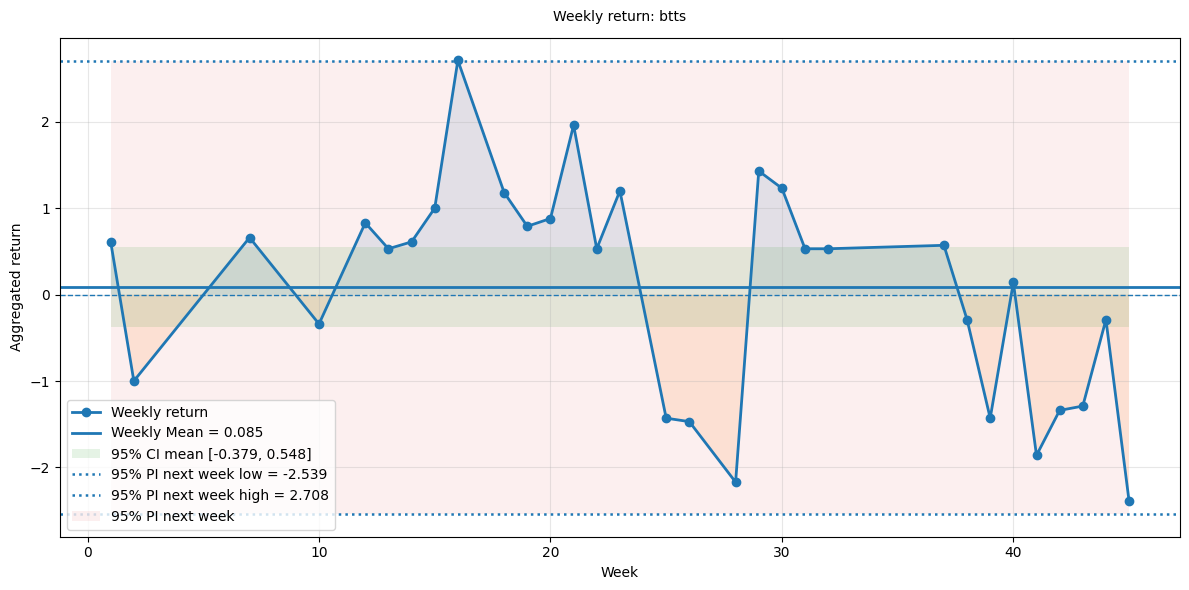

In [249]:
sys.path.append("../..")
from strategies.utils import analyze_strategies, get_best_strategies

df_tot_filtered = pd.concat([df_train_filtered, df_test_filtered], axis=0).reset_index(drop=True).rename(columns={target_col: "result", "time": "date"})
df_tot_filtered = df_tot_filtered.sort_values(by="date", ascending=False)
 
df_tot_filtered["strategy"] = target_col

weekly_return, stats = analyze_strategies(df_tot_filtered, strategies=[target_col], print_pi=True)

In [250]:
weeks = stats["n_weeks"]
total_weeks = max(df["weeks"])

print(f"No. of weeks covered: {weeks}/{total_weeks} ({np.round((weeks/total_weeks), 2)})")

No. of weeks covered: 31/45 (0.69)


In [251]:
get_best_strategies(df_tot_filtered)

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
btts,0.08,1.26,1.93,1.89,87,0.71


In [230]:
def dict_to_range_text(d):
    grouped = {}

    for key, value in d.items():
        if key.endswith('_use_min'):
            base = key[:-8]
            grouped.setdefault(base, {})['use_min'] = value
        elif key.endswith('_use_max'):
            base = key[:-8]
            grouped.setdefault(base, {})['use_max'] = value
        elif key.endswith('_min'):
            base = key[:-4]
            grouped.setdefault(base, {})['min'] = value
        elif key.endswith('_max'):
            base = key[:-4]
            grouped.setdefault(base, {})['max'] = value
        elif key.endswith('_cat'):
            base = key[:-4]
            grouped.setdefault(base, {})['cat'] = value

    lines = []

    for base, vals in grouped.items():
        if 'cat' in vals:
            cats = [x for x in vals['cat'] if x != '<NA>']
            lines.append(f"{base}: categorie ammesse = {', '.join(map(str, cats))}")
            continue

        use_min = vals.get('use_min', False)
        use_max = vals.get('use_max', False)
        min_val = vals.get('min')
        max_val = vals.get('max')

        if use_min and use_max:
            lines.append(f"{base}: tra {min_val} e {max_val}")
        elif use_min:
            lines.append(f"{base}: >= {min_val}")
        elif use_max:
            lines.append(f"{base}: <= {max_val}")
        else:
            lines.append(f"{base}: nessun vincolo")

    return "\n".join(lines)

text = dict_to_range_text(params_dict)
print(text)

goalNoGoal_chance_goalHome: tra 90.0 e 100.0
goalNoGoal_chance_goalAway: <= 100.0
goalNoGoal_comparison_affini: tra 6000 e 16000
underOver_chance_over15HT: tra 40 e 60
underOver_comparison_affini: <= 18000
evaluation_valScala: categorie ammesse = 48727, 49657, 50827
evaluation_valMetrica: categorie ammesse = 354214, 398418, 494608, 757193
